# 1. Environment Setup & Data Acquisition
*Mounting Google Drive and extracting the HMDB51 dataset into the local Colab workspace for optimized I/O operations.*

In [1]:
# 1. use Google Drive
from google.colab import drive
drive.mount('/content/drive')


!cp "/content/drive/MyDrive/FDL_Project/dataset.zip" "/content/"


# 3. unzip the dataset (-q means quite)
print("unzipping, please wait 1 minute...")
!unzip -q /content/dataset.zip -d /content/
print("unzip finished!")

Mounted at /content/drive
正在解压数据集，请稍等大约 1 分钟...
解压完成！准备战斗！


# 2. Workspace Configuration & Module Imports
*Dynamically resolving the project root directory and injecting custom modules into the system path to enable modular imports.*

In [69]:
# @title
from pathlib import Path
import json
import random
import shutil
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# =========================================================
# Dynamic Path Resolution
# =========================================================
def find_project_root(start_path: Path, max_levels_up: int = 5) -> Path:
    """
    Traverses upwards from the current directory to locate the project root.
    The root is identified by the presence of both the source code directory
    ('hmdb_classifier') and the dataset directory ('hmdb51_org').
    """
    current = start_path.resolve()
    for _ in range(max_levels_up):
        # locate /hmdb_classifier and /hmdb51_org
        if (current / 'hmdb_classifier').is_dir() and (current / 'hmdb51_org').is_dir():
            return current

        parent = current.parent
        if parent == current:
            break
        current = parent

    return None

# Execute path resolution
PROJECT_ROOT = find_project_root(Path.cwd())

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "[ERROR] Path resolution failed. Could not locate the project root.\n"
        "Please ensure both 'hmdb_classifier' and 'hmdb51_org' exist in the same parent directory."
    )

# Inject the project root into sys.path to enable absolute imports
# from the custom 'hmdb_classifier' package.
sys.path.insert(0, str(PROJECT_ROOT))

from hmdb_classifier.prepare_dataset import build_manifests
from hmdb_classifier.data import make_dataset, read_class_names, read_manifest
from hmdb_classifier.models import build_model
from hmdb_classifier.metrics import evaluate_to_dir, plot_training_history
from hmdb_classifier.video_io import decode_video

print('[INFO] Workspace root correctly identified! Project root:', PROJECT_ROOT)
print('[INFO] TensorFlow version:', tf.__version__)

✅ 自动寻路成功！Project root: /content
✅ TensorFlow version: 2.20.0


# 3. Global Configurations & Hyperparameters
*Defining project paths, model architecture settings, and training hyperparameters. Global random seeds are fixed to ensure complete reproducibility of the experiment.*

In [70]:
# =========================================================
# 1. Directory Paths
# =========================================================
DATA_ROOT = PROJECT_ROOT / 'hmdb51_org'
# SPLITS_ROOT = PROJECT_ROOT / 'testTrainMulti_7030_splits'
SPLITS_ROOT = PROJECT_ROOT / 'test_train_splits'
MANIFEST_DIR = PROJECT_ROOT / 'data' / 'manifests'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'

# =========================================================
# 2. Experiment & Split Settings
# =========================================================
SPLIT_ID = 1    # Official HMDB51 split ID (1, 2, or 3), here we choose 1
VAL_RATIO = 0.15    # Proportion of training data reserved for validation
SEED = 42

# =========================================================
# 3. Model Architecture Configuration
# =========================================================
MODEL_NAME = 'mobilenet_gru'   # Options: 'mobilenet_gru', 'mobilenet_avg', or 'conv3d'
WEIGHTS = 'imagenet'           # Use 'none' to train from scratch without pre-trained weights
FINE_TUNE_BACKBONE = True        # True for Stage-2 partial unfreezing; False to completely freeze the backbone
DROPOUT = 0.4

# =========================================================
# 4. Training Hyperparameters
# =========================================================
FRAMES = 16             # Temporal dimension: Number of frames sampled per video
IMAGE_SIZE = 96         # Spatial dimension: Target resolution (H x W) Adjust based on CPU RAM)
BATCH_SIZE = 64           # Number of samples per batch (Adjust based on GPU VRAM)
EPOCHS = 30             # Maximum number of training epochs
LEARNING_RATE = 1e-4        # Optimizer learning rate
QUICK_LIMIT_PER_CLASS = None    # Set to a small int (e.g., 2) for quick pipeline debugging; None for full dataset
CACHE_DATASET = True          # Enable tf.data caching to eliminate I/O bottlenecks (Requires sufficient RAM)

# =========================================================
# 5. Enforce Deterministic Behavior
# =========================================================
# Fixing seeds across all libraries guarantees that the
# dataset shuffling, weight initialization, and dropout behave exactly the same across runs.
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print(f"[INFO] Hyperparameters successfully loaded. Target Model: {MODEL_NAME}, Frames: {FRAMES}")

# 4. Dataset Integrity Verification (Sanity Check)
*Scanning the local directory to verify that all action classes and video clips have been correctly extracted without data loss.*

In [71]:
# Scan for class directories and video files
class_dirs = sorted(path for path in DATA_ROOT.iterdir() if path.is_dir())
video_paths = sorted(DATA_ROOT.glob('*/*.avi'))

# Validate dataset completeness
print('Total action classes found:', len(class_dirs))
print('Total video files found:', len(video_paths))
print('Sample classes (First 10):', [path.name for path in class_dirs[:10]])


Numero classi: 51
Numero video: 6766
Prime 10 classi: ['brush_hair', 'cartwheel', 'catch', 'chew', 'clap', 'climb', 'climb_stairs', 'dive', 'draw_sword', 'dribble']


# 5. Data Splitting & Manifest Generation
*Parsing the official HMDB51 splits and generating lightweight index files (manifests). A validation subset is dynamically carved out from the training pool based on the defined `VAL_RATIO`.*

In [72]:
print("[INFO] Building data manifests (Indexing videos & labels)...")
summary = build_manifests(
    data_root=DATA_ROOT,
    splits_root=SPLITS_ROOT,
    manifest_dir=MANIFEST_DIR,
    split_id=SPLIT_ID,
    val_ratio=VAL_RATIO,
    seed=SEED,
)


# Display the distribution of video clips across the three sets
print("\n" + "=" * 50)
print("[INFO] Dataset Split Distribution:")
print("=" * 50)
print(json.dumps(summary['counts'], indent=4))
print("=" * 50)
print(f"[INFO] Manifests successfully saved to: {MANIFEST_DIR}")

{
  "official": {
    "train": 3570,
    "unused": 1666,
    "test": 1530
  },
  "generated": {
    "train": 3060,
    "val": 510,
    "test": 1530,
    "unused": 1666
  },
  "classes": 51,
  "missing_files": 0,
  "total_existing_in_split_files": 6766
}
Manifest directory: /content/data/manifests


# 6. Data Record Ingestion
*Loading the structured manifests into memory. These records act as lightweight pointers for the TensorFlow data pipeline, ensuring memory-efficient video loading.*

In [73]:
# Define absolute paths for the generated manifest files
CLASSES_PATH = MANIFEST_DIR / 'classes.txt'
TRAIN_MANIFEST = MANIFEST_DIR / f'split{SPLIT_ID}_train.csv'
VAL_MANIFEST = MANIFEST_DIR / f'split{SPLIT_ID}_val.csv'
TEST_MANIFEST = MANIFEST_DIR / f'split{SPLIT_ID}_test.csv'

# Load video pointers and labels into memory (Not the heavy video files yet)
print("[INFO] Ingesting data records from manifests...")
class_names = read_class_names(CLASSES_PATH)
train_records = read_manifest(TRAIN_MANIFEST, limit_per_class=QUICK_LIMIT_PER_CLASS, seed=SEED)
val_records = read_manifest(VAL_MANIFEST, limit_per_class=QUICK_LIMIT_PER_CLASS, seed=SEED)
test_records = read_manifest(TEST_MANIFEST, limit_per_class=QUICK_LIMIT_PER_CLASS, seed=SEED)

# Output the final data pipeline inventory as a clean dashboard
print("[INFO] Data Ingestion Summary")
print('Class:', len(class_names))
print('Train:', len(train_records))
print('Validation:', len(val_records))
print('Test:', len(test_records))
print('Sample Record (Train):', train_records[0])

Classi: 51
Train: 3060
Validation: 510
Test: 1530
Esempio record: {'path': '/content/hmdb51_org/sword_exercise/Blade_Of_Fury_-_Scene_1_sword_exercise_f_nm_np1_ri_med_1.avi', 'label': 45, 'class_name': 'sword_exercise', 'subset': 'train'}


# 7. Visual Inspection & Decoding Verification
*Randomly sampling a video from the training set to visually verify the frame decoding, spatial resizing, and temporal sampling logic. This acts as a visual sanity check before feeding tensors into the neural network.*

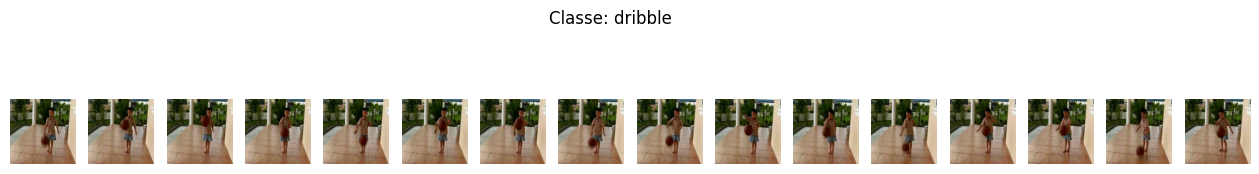

In [74]:
# Randomly select one video record from the training set

sample = random.choice(train_records)
print(f"[INFO] Visualizing decoding pipeline...")
print(f"[INFO] Target Class: {sample['class_name']}")
print(f"[INFO] Source Path : {sample['path']}")

# Decode the video using global hyperparameters to ensure consistency
# (Avoids hardcoding numbers like 16 or 128)
video = decode_video(sample['path'], frame_count=16, image_size=128)

# Plot the temporal sequence of extracted frames
# Create a horizontal strip of subplots matching the number of frames

fig, axes = plt.subplots(1, 16, figsize=(16, 2.2))
for index, ax in enumerate(axes):
    ax.imshow(video[index])
    ax.axis('off') # Hide axes for a cleaner visual strip
fig.suptitle(f"Class: {sample['class_name']}", y=1.05)
plt.show()

# 8. High-Performance Data Pipeline Assembly
*Constructing the highly optimized `tf.data.Dataset` pipelines. This stage integrates TSN temporal sampling, spatial resizing, batching, and conditional caching. A single batch is fetched to verify tensor dimensions and pixel normalization bounds.*

In [75]:
print("[INFO] Constructing tf.data.Dataset pipelines...")

# 1. Training Pipeline (With Temporal Jittering & Dynamic Augmentation)
train_ds, train_count = make_dataset(
    TRAIN_MANIFEST,
    frame_count=FRAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    training=True,  # Enables random temporal shifting (TSN) to prevent overfitting
    seed=SEED,
    limit_per_class=QUICK_LIMIT_PER_CLASS,
    cache=CACHE_DATASET,    # Conditional caching to optimize disk I/O
)

# 2. Validation Pipeline (Strict uniform sampling for fair evaluation)
val_ds, val_count = make_dataset(
    VAL_MANIFEST,
    frame_count=FRAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    training=False, # Disables randomness; ensures deterministic evaluation
    seed=SEED,
    limit_per_class=QUICK_LIMIT_PER_CLASS,
    cache=CACHE_DATASET,
)

# 3. Official Test Pipeline (Hold-out set for final evaluation)
test_ds, test_count = make_dataset(
    TEST_MANIFEST,
    frame_count=FRAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    training=False,      # Strict uniform sampling
    seed=SEED,
    limit_per_class=QUICK_LIMIT_PER_CLASS,
    cache=CACHE_DATASET,
)

# =========================================================
# Tensor Sanity Check: Inspecting the structural integrity of a single batch
# =========================================================
for batch_videos, batch_labels in train_ds.take(1):
    # Expected shape: (Batch_Size, Frames, Height, Width, Channels)
    print('Batch video:', batch_videos.shape)
    print('Batch label:', batch_labels.shape)
    print('Range pixel:', float(tf.reduce_min(batch_videos)), float(tf.reduce_max(batch_videos)))

print('Train records:', train_count)
print('Validation records:', val_count)

Batch video: (64, 16, 96, 96, 3)
Batch label: (64,)
Range pixel: 0.0 1.0
Train records: 3060
Validation records: 510


# 9. Model Architecture & Regularized Compilation
*Instantiating the Two-Stream conceptual architecture (MobileNetV2 + GRU). To prevent over-confidence and mitigate overfitting during Stage-2 fine-tuning, Label Smoothing Regularization is implemented. Stage-1 pre-trained weights are dynamically injected prior to compilation.*

In [76]:
print(f"[INFO] Instantiating the neural architecture: {MODEL_NAME}...")

# 1. Build the core model
model = build_model(
    model_name=MODEL_NAME,
    num_classes=len(class_names),
    frame_count=FRAMES,
    image_size=IMAGE_SIZE,
    weights=WEIGHTS,
    backbone_trainable=FINE_TUNE_BACKBONE,
    dropout=DROPOUT,
)


# =========================================================
# Custom Loss Function: Label Smoothing Regularization
# =========================================================
# Label smoothing prevents the model from predicting overly confident probabilities,
# which acts as a strong regularizer for fine-grained action classification.

loss_fn = tf.keras.losses.CategoricalCrossentropy(
    label_smoothing=0.1
)


def smoothed_loss(y_true, y_pred):
    """
    Dynamically converts sparse integer labels into one-hot encoded vectors
    on the computational graph before applying the smoothed crossentropy loss.
    """
    y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=len(class_names))
    return loss_fn(y_true_one_hot, y_pred)



# =========================================================
# Compilation & Metric Tracking
# =========================================================
print("[INFO] Compiling model with Adam optimizer and Smoothed Loss...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=smoothed_loss,# use smoothed loss here
    metrics=[
        'accuracy',
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=min(5, len(class_names)), name='top5_accuracy'),
    ],
)

model.summary()
# =========================================================
# Stage-2 Initialization: Injecting Stage-1 Weights
# =========================================================
if FINE_TUNE_BACKBONE:
    # Path to the best weights achieved during Stage-1 (Frozen Backbone)
    STAGE1_WEIGHTS_PATH = '/content/current stage1 results/best_model.keras'
    model.load_weights(STAGE1_WEIGHTS_PATH)
    print("Weight initialization successful. The model is primed for fine-grained adaptation.")



[OK] MobileNetV2: pesi ImageNet caricati.
[TACTICS] 局部解冻开启：前 110 层已锁死，仅微调高层神经元！


Model: "mobilenet_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video (InputLayer)              │ (None, 16, 96, 96, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocess            │ (None, 16, 96, 96, 3)  │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_encoder (TimeDistributed) │ (None, 16, 1280)       │     2,257,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_norm                   │ (None, 16, 1280)       │         2,560 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_gru               │ (None, 256)            │     1,082,880 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probs (Dense)             │ (None, 51)             │        13,107 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,422,323 (13.06 MB)

 Trainable params: 2,907,507 (11.09 MB)

 Non-trainable params: 514,816 (1.96 MB)

✅ 第一阶段记忆注入成功！模型已戴上眼镜，准备精细化雕刻！


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# 10. Model Training & Checkpointing
*Setting up the run directory, saving hyperparameters, and executing the training loop with callbacks for early stopping and learning rate reduction.*

In [77]:
# Setup run directory based on current timestamp
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
RUN_NAME = f'{timestamp}_split{SPLIT_ID}_{MODEL_NAME}_notebook'
RUN_DIR = OUTPUT_DIR / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=False)

# Backup classes and save training configuration
shutil.copyfile(CLASSES_PATH, RUN_DIR / 'classes.txt')
with (RUN_DIR / 'notebook_config.json').open('w', encoding='utf-8') as handle:
    json.dump(
        {
            'split_id': SPLIT_ID,
            'val_ratio': VAL_RATIO,
            'seed': SEED,
            'model_name': MODEL_NAME,
            'weights': WEIGHTS,
            'fine_tune_backbone': FINE_TUNE_BACKBONE,
            'dropout': DROPOUT,
            'frames': FRAMES,
            'image_size': IMAGE_SIZE,
            'batch_size': BATCH_SIZE,
            'epochs': EPOCHS,
            'learning_rate': LEARNING_RATE,
            'quick_limit_per_class': QUICK_LIMIT_PER_CLASS,
        },
        handle,
        indent=2,
    )

# Define Callbacks
callbacks = [
    # Save only the best model weights
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(RUN_DIR / 'best_model.keras'),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
    ),
    # Stop training if validation accuracy doesn't improve for 6 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=6,
        restore_best_weights=True,
    ),
    # Reduce learning rate by half if stuck for 3 epochs
    tf.keras.callbacks.ReduceLROnPlateau( # 长期不增加学习率降档
        monitor='val_accuracy',
        mode='max',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
    ),
    # Save metrics to CSV
    tf.keras.callbacks.CSVLogger(str(RUN_DIR / 'history.csv')),
]

# Start Training Loop
print("[INFO] Starting model training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)
print("[INFO] Training completed!")
print('Run directory:', RUN_DIR)

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.4931 - loss: 2.5773 - top5_accuracy: 0.8046 - val_accuracy: 0.5980 - val_loss: 2.3311 - val_top5_accuracy: 0.8412 - learning_rate: 1.0000e-04
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.5850 - loss: 2.2676 - top5_accuracy: 0.8699 - val_accuracy: 0.6118 - val_loss: 2.2984 - val_top5_accuracy: 0.8392 - learning_rate: 1.0000e-04
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.6359 - loss: 2.1016 - top5_accuracy: 0.8886 - val_accuracy: 0.6078 - val_loss: 2.2804 - val_top5_accuracy: 0.8314 - learning_rate: 1.0000e-04
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.6729 - loss: 1.9784 - top5_accuracy: 0.9144 - val_accuracy: 0.6098 - val_loss: 2.2578 - val_top5_accuracy: 0.8451 - learning_rate: 1.0000e-04
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.7095 - loss: 1.8788 - top5_accuracy: 0.9395 - val_accuracy: 0.6333 - val_loss: 2.2472 - val_top5_accuracy: 0.84

# 11. Learning Curves & Final Evaluation
*Plotting the training history to verify model convergence and evaluating the fine-tuned architecture on the hold-out test set. This section computes overall accuracy metrics and generates a diagnostic confusion matrix to identify extreme performance outliers.*

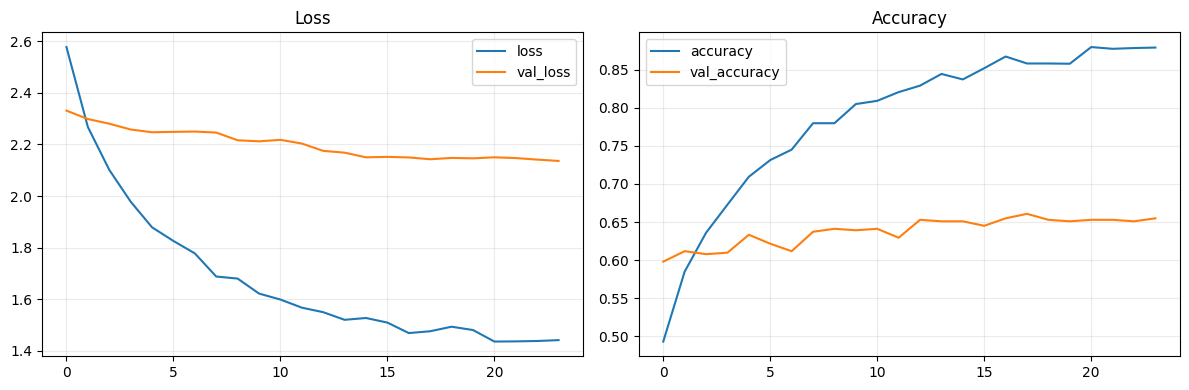

In [78]:
plot_training_history(RUN_DIR / 'history.csv', RUN_DIR / 'training_curves.png')

In [87]:
# =========================================================
# Quantitative Evaluation on Hold-Out Test Set
# =========================================================
print("\n[INFO] Evaluating model on the pure Test Set. Please wait...")

# Run the final evaluation
test_loss, test_acc, test_top5 = model.evaluate(test_ds, verbose=1)

# Display the final scorecard
print("\n" + "=" * 50)
print("[INFO] Final Test Set Metrics")
print("=" * 50)
print(f"🔹 Test Loss          : {test_loss:.4f}")
print(f"🔹 Test Top-1 Accuracy: {test_acc * 100:.2f}%")
print(f"🔹 Test Top-5 Accuracy: {test_top5 * 100:.2f}%")
print("=" * 50)


[INFO] Evaluating model on the pure Test Set. Please wait...
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.6608 - loss: 2.1426 - top5_accuracy: 0.8647 

[INFO] Final Test Set Metrics
🔹 Test Loss          : 2.1426
🔹 Test Top-1 Accuracy: 66.08%
🔹 Test Top-5 Accuracy: 86.47%


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


🚀 正在未知领域 (Test Set) 提取最终预测结果，准备绘制终极混淆矩阵...
✅ 测试集终极混淆矩阵已保存为 HMDB51_TEST_Confusion_Matrix_HighRes.png！


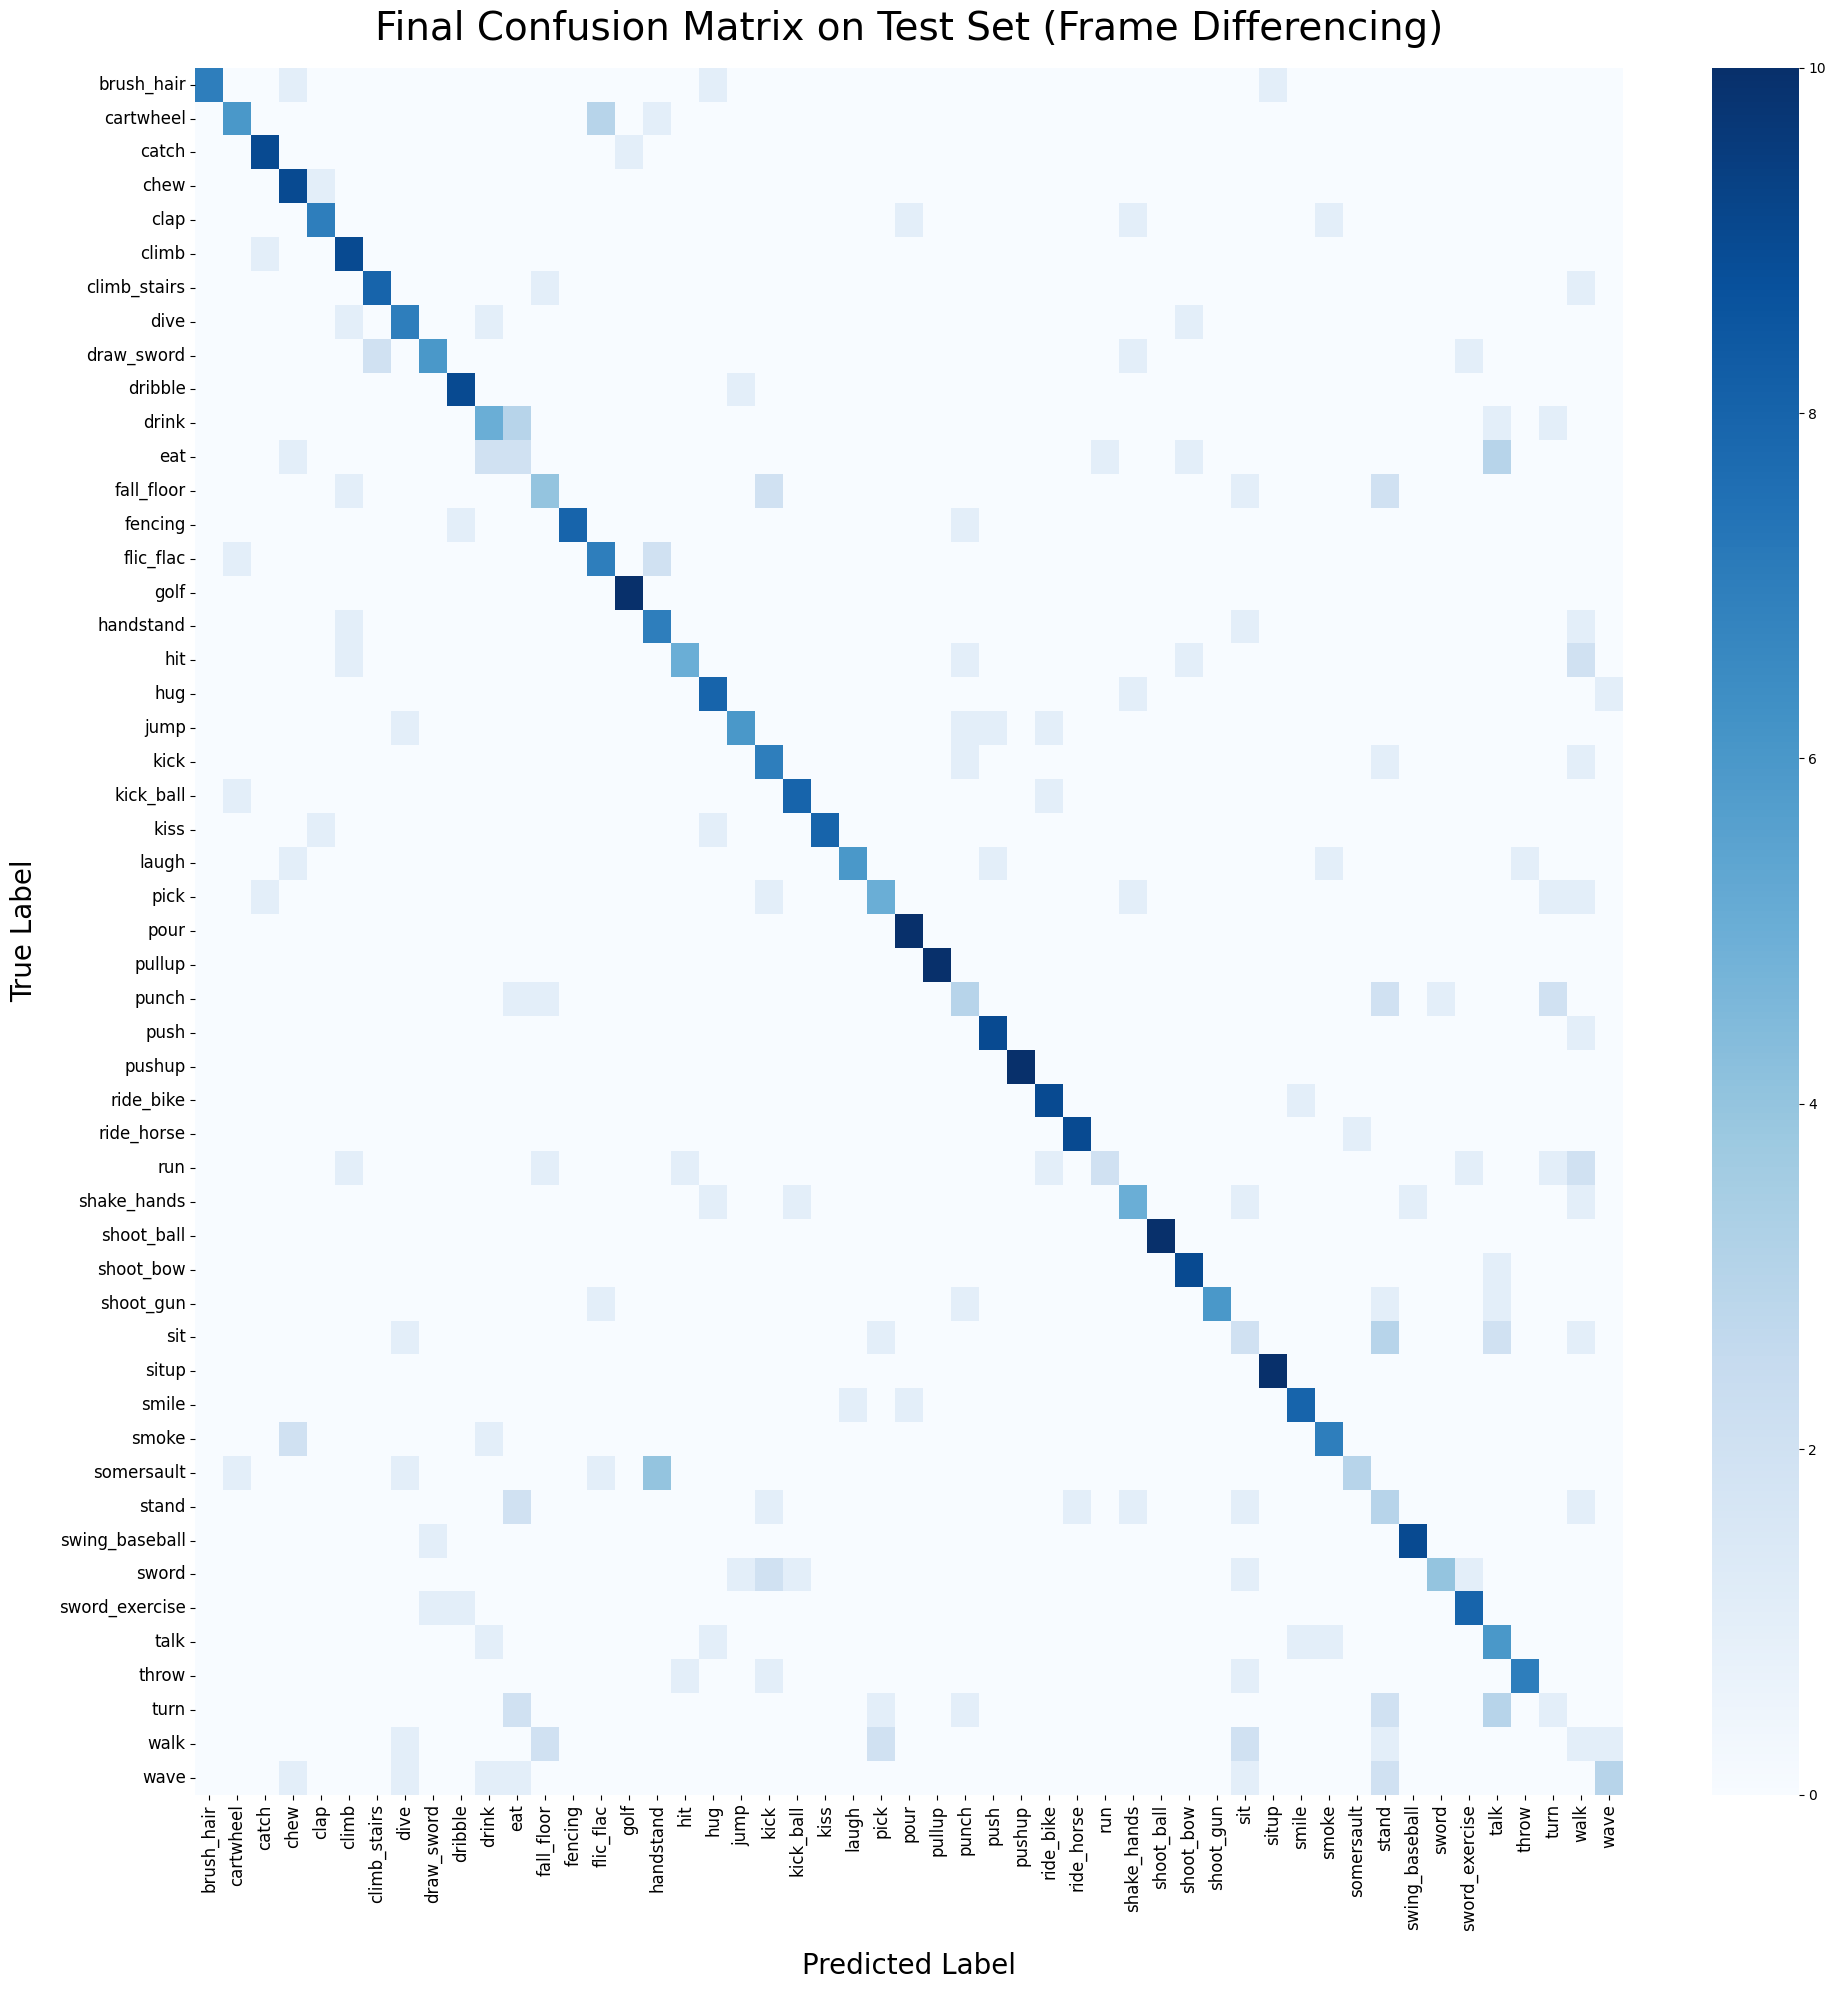


📊 最终测试集：单类准确率极值诊断分析

🏆 表现最好的 3 个动作 (Best 3):
   - golf: 100.0%
   - pour: 100.0%
   - pullup: 100.0%

💔 表现最差的 3 个动作 (Worst 3):
   - sit: 20.0%
   - turn: 10.0%
   - walk: 10.0%


In [86]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Iterate over the test dataset to collect predictions
y_true_test = []
y_pred_probs_test = []

# Iterate over the test dataset to collect predictions
for images, labels in test_ds:
    y_true_test.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs_test.extend(preds)

y_true_test = np.array(y_true_test)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)

# =========================================================
# High-Resolution Confusion Matrix (Test Set)
# =========================================================
cm_test = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(20, 20))
sns.heatmap(cm_test, annot=False, cmap='Blues', fmt='d',
            xticklabels=class_names, yticklabels=class_names)

# 标题换成极其严谨的 Test Set
plt.title('Final Confusion Matrix on Test Set (Frame Differencing)', fontsize=28, pad=20)
plt.xlabel('Predicted Label', fontsize=20, labelpad=15)
plt.ylabel('True Label', fontsize=20, labelpad=15)

plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

# Save the figure locally
plt.savefig('HMDB51_TEST_Confusion_Matrix_HighRes.png', dpi=300)
print("[INFO] High-resolution confusion matrix saved as HMDB51_TEST_Confusion_Matrix_HighRes.png！")
plt.show()

# =========================================================
# Extreme Value Diagnostic Analysis
# =========================================================
print("\n" + "="*50)
print("[INFO] Class-Level Performance Diagnostics (Test Set)")
print("="*50)

report_test = classification_report(y_true_test, y_pred_test, target_names=class_names, output_dict=True)

class_accuracies_test = {}
for cls in class_names:
    if cls in report_test:
        class_accuracies_test[cls] = report_test[cls]['recall']

# Sort classes by accuracy (recall) in descending order
sorted_acc_test = sorted(class_accuracies_test.items(), key=lambda x: x[1], reverse=True)

print("\n[Best Performing Classes (Top 3)]:")
for name, acc in sorted_acc_test[:3]:
    print(f"   - {name}: {acc*100:.1f}%")

print("\n[Worst Performing Classes (Bottom 3)]:")
for name, acc in sorted_acc_test[-3:]:
    print(f"   - {name}: {acc*100:.1f}%")